In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Phase 1: Data Engineering and Unimodal Pipelines**
A: Audio Preprocessing (CNN Input)

In [18]:
# Importing the libraries for loading and preprocessing the data
import librosa
import os
import numpy as np

I have commented out this preprocessing part of the dataset, since this must only be done once.
I have saved the NumPy arrays which contain the conversion of the Mel Spectrograms of the processed audio files
and their corresponding labels to the MyDrive -> Emotion_Recognition_Dataset folder.
I am loading these NumPy arrays in the notebook whenever I reopen it.

Similarly, I have saved the tokenized, encoded and padded versions of the text transcriptions of all the audio files to the same folder and am similarly loading it as a NumPy array in the notebook whenever I reopen it.

In [19]:
"""
# Loading the dataset
# preprocessing the raw audio data
# and extracting the labels and dB levels from the Mel Spectrogram of the processed data

# The path to the folder containing the entire dataset
dataset_folder_path = '/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_data/'

# Creating lists to store the Mel Spectrograms converted to dB and the labels for the emotions
# These lists will later be routed to NumPy arrays and then saved for reloading into the notebook
list_log_mel_spec = []
list_labels = []

# Iterating over all the actor folders
for actor in os.listdir(dataset_folder_path):
  actor_folder_path = os.path.join(dataset_folder_path, actor)
  # Iterating over all the files in a given actor's folder
  for actor_file in os.listdir(actor_folder_path):
    actor_file_path = os.path.join(actor_folder_path, actor_file)

    # Using the file name to figure out what its label is
    # In the RAVDESS Emotional Speech Dataset, the 3rd number in the file name is the label for that
    # corresponding file
    label = int(actor_file.split('-')[2])

    # Loading the file with the original Sample Rate
    audio_raw, sr = librosa.load(actor_file_path, sr=None)

    # Preprocessing:

    # 1: Trimming the audio files (the indexes for the silent parts are ignored by storing them in '_')
    # Applying a top_db filter of 60 dB
    audio_trim, _ = librosa.effects.trim(audio_raw, top_db=60)

    # 2: Normalizing the values in the trimmed audio
    audio_normalize = librosa.util.normalize(audio_trim)

    # 3: Fixing the length of the audio with the normalized values
    # After manually randomly inspecting some of the files from the dataset, I discovered that the typical
    # duration for the audio was 3 to 4 seconds. Since each file contains about 0.5-1.0 seconds worth of silence,
    # it seems appropriate to use a fixed duration of 3 seconds for each processed file
    audio_processed = librosa.util.fix_length(audio_normalize, size=3 * sr)

    # 4: Converting the processed audio to its Mel Spectrogram and then further converting that to the dB values
    audio_mel_spec = librosa.feature.melspectrogram(y=audio_processed, sr=sr)
    db_mel_spec = librosa.power_to_db(audio_mel_spec, ref=np.max)

    # Appending the dB conversion of the Mel Spectrogram and the label of the audio file to the lists
    list_log_mel_spec.append(db_mel_spec)
    list_labels.append(label)
"""

"\n# Loading the dataset\n# preprocessing the raw audio data\n# and extracting the labels and dB levels from the Mel Spectrogram of the processed data\n\n# The path to the folder containing the entire dataset\ndataset_folder_path = '/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_data/'\n\n# Creating lists to store the Mel Spectrograms converted to dB and the labels for the emotions\n# These lists will later be routed to NumPy arrays and then saved for reloading into the notebook\nlist_log_mel_spec = []\nlist_labels = []\n\n# Iterating over all the actor folders\nfor actor in os.listdir(dataset_folder_path):\n  actor_folder_path = os.path.join(dataset_folder_path, actor)\n  # Iterating over all the files in a given actor's folder\n  for actor_file in os.listdir(actor_folder_path):\n    actor_file_path = os.path.join(actor_folder_path, actor_file)\n\n    # Using the file name to figure out what its label is\n    # In the RAVDESS Emotional Speech Dataset, the 3rd number in the

In [20]:
"""
# Creating NumPy arrays out of the lists and saving them to the drive folder
# for future use whenever re-opening the notebook
array_log_mel_spec = np.array(list_log_mel_spec)
array_labels = np.array(list_labels)

np.savez_compressed('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_dBspectrograms.npz', features=array_log_mel_spec, labels=array_labels)
"""

"\n# Creating NumPy arrays out of the lists and saving them to the drive folder\n# for future use whenever re-opening the notebook\narray_log_mel_spec = np.array(list_log_mel_spec)\narray_labels = np.array(list_labels)\n\nnp.savez_compressed('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_dBspectrograms.npz', features=array_log_mel_spec, labels=array_labels)\n"

B: Text Generation and Preprocessing (RNN Input)

In [21]:
"""
# Importing Whisper
import whisper
"""

'\n# Importing Whisper\nimport whisper\n'

In [22]:
"""
# Converting the audio files to text

# The path to the folder containing the entire dataset
dataset_folder_path = '/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_data/'

# Loading the model (using "base")
model = whisper.load_model("base")

# Creating a list to store the text after conversion
# Theis list will later be routed to a NumPy array and then saved for reloading into the notebook
list_text_conversion = []

# Iterating over all the actor folders
for actor in os.listdir(dataset_folder_path):
  actor_folder_path = os.path.join(dataset_folder_path, actor)
  # Iterating over all the files in a given actor's folder
  for actor_file in os.listdir(actor_folder_path):
    actor_file_path = os.path.join(actor_folder_path, actor_file)

    # Using Whisper to convert the speech to text
    converted_data = model.transcribe(actor_file_path)
    text = converted_data['text'].strip()

    # Appending the text to the list
    list_text_conversion.append(text)
"""

'\n# Converting the audio files to text\n\n# The path to the folder containing the entire dataset\ndataset_folder_path = \'/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_data/\'\n\n# Loading the model (using "base")\nmodel = whisper.load_model("base")\n\n# Creating a list to store the text after conversion\n# Theis list will later be routed to a NumPy array and then saved for reloading into the notebook\nlist_text_conversion = []\n\n# Iterating over all the actor folders\nfor actor in os.listdir(dataset_folder_path):\n  actor_folder_path = os.path.join(dataset_folder_path, actor)\n  # Iterating over all the files in a given actor\'s folder\n  for actor_file in os.listdir(actor_folder_path):\n    actor_file_path = os.path.join(actor_folder_path, actor_file)\n\n    # Using Whisper to convert the speech to text\n    converted_data = model.transcribe(actor_file_path)\n    text = converted_data[\'text\'].strip()\n\n    # Appending the text to the list\n    list_text_conversion.a

In [23]:
"""
# Creating a NumPy array out of the list and saving it to the drive folder
# for future use whenever re-opening the notebook
array_text_conversion = np.array(list_text_conversion)

np.savez_compressed('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_text.npz', text_data=array_text_conversion)
"""

"\n# Creating a NumPy array out of the list and saving it to the drive folder\n# for future use whenever re-opening the notebook\narray_text_conversion = np.array(list_text_conversion)\n\nnp.savez_compressed('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_text.npz', text_data=array_text_conversion)\n"

In [24]:
"""
# Tokenizing, Encoding and Padding the Text

# Using the "bert-base-uncased" tokenizer from Hugging Face
from transformers import AutoTokenizer
text_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text_transcriptions_data = np.load('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_text.npz')
text_transcriptions = text_transcriptions_data['text_data']

# Using Pre-Padding, because this helps keep the actual data closer to the end of the pipeline for the LSTM
text_tokenizer.padding_side = "left"

# Processing inside the tokenizer with a fixed length of 10
# The fixed length was decided using trial and error to keep as less unused padding 0s as possible
# Returning a NumPy array
encoded_tokenized_text = text_tokenizer(
    text_transcriptions.tolist(),
    padding='max_length',
    max_length=12,
    truncation=True,
    return_tensors="np"
)

# Saving the NumPy array of encoded and tokenized text to the drive folder
# for future use whenever re-opening the notebook
encoded_tokenized_text_encodings = encoded_tokenized_text['input_ids']
np.savez_compressed('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_tokenized_encoded_text.npz', tokenized_encoded_text_data=encoded_tokenized_text_encodings)
"""

'\n# Tokenizing, Encoding and Padding the Text\n\n# Using the "bert-base-uncased" tokenizer from Hugging Face\nfrom transformers import AutoTokenizer\ntext_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")\n\ntext_transcriptions_data = np.load(\'/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_text.npz\')\ntext_transcriptions = text_transcriptions_data[\'text_data\']\n\n# Using Pre-Padding, because this helps keep the actual data closer to the end of the pipeline for the LSTM\ntext_tokenizer.padding_side = "left"\n\n# Processing inside the tokenizer with a fixed length of 10\n# The fixed length was decided using trial and error to keep as less unused padding 0s as possible\n# Returning a NumPy array\nencoded_tokenized_text = text_tokenizer(\n    text_transcriptions.tolist(),\n    padding=\'max_length\',\n    max_length=12,\n    truncation=True,\n    return_tensors="np"\n)\n\n# Saving the NumPy array of encoded and tokenized text to the drive folder\n# for

C: Unimodal Training

Audio CNN

In [25]:
# Importing the necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Loading the dB conversion of the Mel Spectrograms and the labels from the drive
spectrogram_and_label_data = np.load('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_dBspectrograms.npz')
X_cnn = spectrogram_and_label_data['features']
y_cnn = spectrogram_and_label_data['labels']

# Verifying the shape of the spectrogram array X and the label array y
print("Original dimensions of the spectrogram and label arrays respectively:")
print(X_cnn.shape)
print(y_cnn.shape)

# Reshaping the X array to include a dimension for channels (required for the CNN architecture to be created later)
# Since the PyTorch architecture loads data in the format of (Channels, Height, Width), we must add the Channels column
# at axis=1
X_cnn = np.expand_dims(X_cnn, axis=1)
print()
print("New dimensions of the spectrogram array:")
print(X_cnn.shape)

Original dimensions of the spectrogram and label arrays respectively:
(1440, 128, 282)
(1440,)

New dimensions of the spectrogram array:
(1440, 1, 128, 282)


In [ ]:
# Now, for training with PyTorch, the labels must be converted from the range 1-8
# to the range 0-7
y_cnn -= 1

# Splitting the data into a train-validation-test split with a 80%-10%-10% proportion
X_non_test_cnn, X_test_cnn, y_non_test_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.1, random_state=42, stratify=y_cnn
)
X_train_cnn, X_validation_cnn, y_train_cnn, y_validation_cnn = train_test_split(
    X_non_test_cnn, y_non_test_cnn, test_size=0.11, random_state=42, stratify=y_non_test_cnn
)

In [ ]:
# Wrapping the processed data into a PyTorch Dataset
class AudioDataset(Dataset):
    def __init__(self, spectrograms, labels):
        self.spectrograms = torch.tensor(spectrograms).float()
        self.labels = torch.tensor(labels).long()

    def __len__(self):
      return len(self.labels)

    def __getitem__(self, index):
      return self.spectrograms[index], self.labels[index]

# Creating the DataLoader instances for training, validation and testing
# The validation and testing set is not shuffled since we must maintain the same data loading order to
# compare the validation loss among various epochs
train_loader_cnn = DataLoader(AudioDataset(X_train_cnn, y_train_cnn), batch_size=32, shuffle=True)
validation_loader_cnn = DataLoader(AudioDataset(X_validation_cnn, y_validation_cnn), batch_size=32, shuffle=False)
test_loader_cnn = DataLoader(AudioDataset(X_test_cnn, y_test_cnn), batch_size=32, shuffle=False)

In [ ]:
# Creating the CNN Architecture

class CNN(nn.Module):
    def __init__(self, channels, height, width, classes):
        super().__init__()

        # Initializing the model parameters
        # The dimensions of the input data and the number of categorical classes
        self.channels = channels
        self.height = height
        self.width = width
        self.classes = classes

        # Dividing the dimensions of the original data as per the architecture
        # In this instance, there are 4 MaxPools
        for i in range(4):
            self.height = self.height // 2
            self.width = self.width // 2

        # Defining the layers of the CNN:
        self.layers = nn.Sequential(
            # The Convolutional Layers
            nn.Conv2d(self.channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),

            # Flattening the output from the convolutional layers
            nn.Flatten(),

            # The Fully Connected Layers
            nn.Linear(128 * self.height * self.width, 128),
            nn.ReLU(),

            # Adding a dropout of 0.3 for more robust generalization
            nn.Dropout(0.3),

            # Completing the Fully Connected Layers
            # Here, softmax is not used as the final layer, beacuse while training,
            # the Cross-Entropy Loss from PyTorch is being used which automatically converts the
            # logits to softmax values.
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, self.classes)
        )

    # Defining the forward pass
    def forward(self, spectrogram):
        return self.layers(spectrogram)

In [ ]:
# Creating the training and validation loop for the CNN

# Importing MatPlotLib to generate the training and validation loss plots
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_and_validate_CNN(model, train_loader, validation_loader, epochs, lr):
  model.to(device)

  # Using the Adam Optimizer
  optimizer = optim.Adam(model.parameters(), lr=lr)

  # Using the Categorical Cross Entropy Loss
  CCELoss = nn.CrossEntropyLoss()

  training_losses = []
  validation_losses = []
  validation_accuracies_pct = []

  for epoch in range(epochs):
    # Training:
    model.train()
    total_training_loss = 0

    for spectrogram, label in train_loader:
      spectrogram = spectrogram.to(device)
      label = label.to(device)

      optimizer.zero_grad()

      # Forward pass
      predicted_label = model.forward(spectrogram)

      # Calculating the loss
      loss = CCELoss(predicted_label, label)
      total_training_loss += loss.item()

      # Backpropagation
      loss.backward()

      # Optimizer step
      optimizer.step()

    # Printing the total training loss for that epoch:
    training_losses.append(total_training_loss)
    print(f"Epoch {epoch + 1}:")
    print(f"Training Loss = {total_training_loss:.4f}")

    # Validation:
    model.eval()
    total_validation_loss = 0
    correct_predictions = 0

    with torch.no_grad():
      for spectrogram, label in validation_loader:
        spectrogram = spectrogram.to(device)
        label = label.to(device)

        # Forward pass
        predicted_label = model.forward(spectrogram)

        # Calculating the loss
        loss = CCELoss(predicted_label, label)
        total_validation_loss += loss.item()

        # Calculating the accuracy
        # Obtaining the predictions from the tensors of class probabilities
        predictions = predicted_label.argmax(dim=1, keepdim=True)
        # Comparing the individual label predictions with the true labels and adding the
        # number of correct predictions to the total
        correct_predictions += predictions.eq(label.view_as(predictions)).sum().item()

    validation_accuracy = (correct_predictions/len(validation_loader.dataset))*100
    validation_losses.append(total_validation_loss)
    validation_accuracies_pct.append(validation_accuracy)
    # Printing the total validation loss and validation accuracy for that epoch:
    print(f"Validation Loss = {total_validation_loss:.4f}")
    print(f"Validation Accuracy = {validation_accuracy:.4f}%")
    print()

  # Plotting the training and validation loss plots along with the validation accuracy plot
  plt.figure(figsize=(6, 12))

  plt.subplot(3, 1, 1)
  plt.plot([(i+1) for i in range(epochs)], training_losses, color='red')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Training Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(3, 1, 2)
  plt.plot([(i+1) for i in range(epochs)], validation_losses, color='blue')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Validation Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(3, 1, 3)
  plt.plot([(i+1) for i in range(epochs)], validation_accuracies_pct, color='green')
  plt.ylabel("Accuracy (%)")
  plt.ylim(0, 100)
  plt.title("Accuracy Plot")
  plt.xlabel("Epoch")
  plt.grid(True, alpha=0.3)

  plt.suptitle(f"Training, Validation and Accuracy Plots\nEpochs = {epochs}, Learning Rate = {lr}")
  plt.show()

In [ ]:
# Creating the testing loop for the CNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def test_CNN(model, test_loader):
  model.to(device)

  # Testing:
  model.eval()
  correct_predictions = 0
  predictions_list = []

  with torch.no_grad():
    for spectrogram, label in test_loader:
      spectrogram = spectrogram.to(device)
      label = label.to(device)

      # Forward pass
      predicted_label = model.forward(spectrogram)

      # Calculating the accuracy
      # Obtaining the predictions from the tensors of class probabilities
      predictions = predicted_label.argmax(dim=1, keepdim=True)
      predictions_list.extend(predictions.cpu())
      # Comparing the individual label predictions with the true labels and adding the
      # number of correct predictions to the total
      correct_predictions += predictions.eq(label.view_as(predictions)).sum().item()

  test_accuracy = (correct_predictions/len(test_loader.dataset))*100
  # Printing the test accuracy:
  print(f"Test Accuracy = {test_accuracy:.4f}%")

  predictions_array = np.array(predictions_list)

  # Returning the predicted labels for the test dataset
  return predictions_array.flatten()

Epoch 1:
Training Loss = 75.2370
Validation Loss = 9.8820
Validation Accuracy = 27.9720%

Epoch 2:
Training Loss = 71.1406
Validation Loss = 9.3299
Validation Accuracy = 26.5734%

Epoch 3:
Training Loss = 65.8510
Validation Loss = 9.0181
Validation Accuracy = 31.4685%

Epoch 4:
Training Loss = 63.0843
Validation Loss = 8.6770
Validation Accuracy = 30.0699%

Epoch 5:
Training Loss = 56.0652
Validation Loss = 7.7606
Validation Accuracy = 48.2517%

Epoch 6:
Training Loss = 53.3375
Validation Loss = 7.8053
Validation Accuracy = 38.4615%

Epoch 7:
Training Loss = 49.6192
Validation Loss = 7.4479
Validation Accuracy = 40.5594%

Epoch 8:
Training Loss = 48.2136
Validation Loss = 7.4238
Validation Accuracy = 44.7552%

Epoch 9:
Training Loss = 41.2747
Validation Loss = 7.3573
Validation Accuracy = 46.1538%

Epoch 10:
Training Loss = 35.8877
Validation Loss = 8.6957
Validation Accuracy = 34.2657%

Epoch 11:
Training Loss = 33.2713
Validation Loss = 5.8285
Validation Accuracy = 54.5455%

Epoch 12

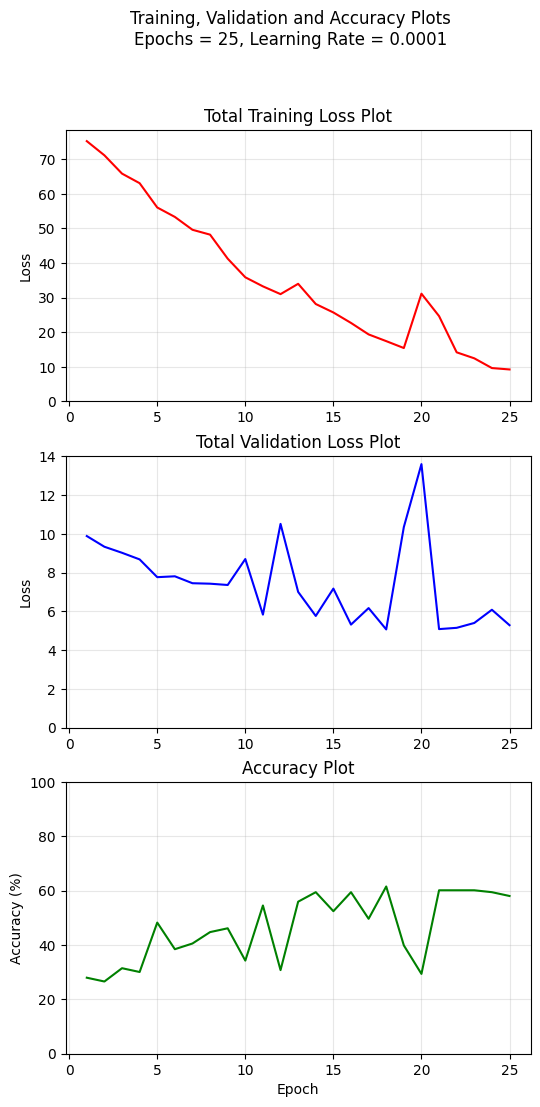

In [ ]:
# Initializing the CNN Model
EPOCHS = 25
LEARNING_RATE = 0.0001
model_cnn = CNN(1, 128, 282, 8)

# Training it
train_and_validate_CNN(model_cnn, train_loader_cnn, validation_loader_cnn, EPOCHS, LEARNING_RATE)

In [ ]:
# Creating the Confusion Matrix Function to plot the normalized Confuion Matrix for the
# true and predicted labels

from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred):
  emotions = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

  # Creating the Confusion Matrix
  matrix = confusion_matrix(y_true, y_pred)
  # Normalizing it by the true predictions per category
  norm_matrix = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

  # Plotting the Normalized Confusion Matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(
      norm_matrix,
      annot=True,
      cmap='coolwarm',
      fmt='.2f',
      xticklabels=emotions,
      yticklabels=emotions
      )
  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Normalized Confusion Matrix for Labels")
  plt.tight_layout()
  plt.show()

Text RNN

In [ ]:
# Loading the tokenized, encoded and padded text from the drive
text_input_data = np.load('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_tokenized_encoded_text.npz', allow_pickle=True)
X_rnn = text_input_data['tokenized_encoded_text_data']
# Loading the labels from the drive
label_data = np.load('/content/drive/MyDrive/Emotion_Recognition_Dataset/ravdess_dataset_dBspectrograms.npz', allow_pickle=True)
y_rnn = label_data['labels']

# Verifying the shape of the tokenized text array X and the label array y
print("Dimensions of the tokenized text and label arrays respectively:")
print(X_rnn.shape)
print(y_rnn.shape)

Dimensions of the tokenized text and label arrays respectively:
(1440, 12)
(1440,)


In [ ]:
# Now, for training with PyTorch, the labels must be converted from the range 1-8
# to the range 0-7
y_rnn -= 1

# Obtaining the vocabulary size of the tokenized text to be used in the LSTM in PyTorch
vocab_size = (X_rnn.max() + 1)

# Splitting the data into a train-validation-test split with a 80%-10%-10% proportion
X_non_test_rnn, X_test_rnn, y_non_test_rnn, y_test_rnn = train_test_split(
    X_rnn, y_rnn, test_size=0.1, random_state=42, stratify=y_rnn
)
X_train_rnn, X_validation_rnn, y_train_rnn, y_validation_rnn = train_test_split(
    X_non_test_rnn, y_non_test_rnn, test_size=0.11, random_state=42, stratify=y_non_test_rnn
)

In [ ]:
# Wrapping the processed data into a PyTorch Dataset
class TextDataset(Dataset):
    def __init__(self, tokenized_text, labels):
        self.tokenized_text = torch.tensor(tokenized_text).int()
        self.labels = torch.tensor(labels).long()

    def __len__(self):
      return len(self.labels)

    def __getitem__(self, index):
      return self.tokenized_text[index], self.labels[index]

# Creating the DataLoader instances for training, validation and testing
# The validation and training set is not shuffled since we must maintain the same data loading order to
# compare the validation loss among various epochs
train_loader_rnn = DataLoader(TextDataset(X_train_rnn, y_train_rnn), batch_size=32, shuffle=True)
validation_loader_rnn = DataLoader(TextDataset(X_validation_rnn, y_validation_rnn), batch_size=32, shuffle=False)
test_loader_rnn = DataLoader(TextDataset(X_test_rnn, y_test_rnn), batch_size=32, shuffle=False)

In [ ]:
# Creating the RNN architecture: Using an LSTM from PyTorch

class LSTM(nn.Module):
  def __init__(self, vocab_size, emb_dim, hidden_dim, output_dim):
    super().__init__()

    # Initializing the model parameters
    # The vocabulary size and number of dimensions for the embeddings, hidden layers
    # and the output
    self.vocab_size = vocab_size
    self.emb_dim = emb_dim
    self.hidden_dim = hidden_dim
    self.output_dim = output_dim

    # Defining the embedding layer for the tokenized text input
    self.text_embed = nn.Embedding(self.vocab_size, self.emb_dim)

    # Defining the LSTM
    self.lstm = nn.LSTM(
        input_size=self.emb_dim,
        hidden_size=self.hidden_dim,
        num_layers=1,
        batch_first=True,
    )

    # Defining the Fully Connected Layer
    self.fc_layers = nn.Sequential(
        nn.Linear(self.hidden_dim, 16),
        nn.ReLU(),
        nn.Linear(16, self.output_dim)
    )

  # Defining the forward pass
  def forward(self, tokenized_text):
    # Embedding the input tokenized text
    embedded_text = self.text_embed(tokenized_text)
    # Processing the embedding through the LSTM
    output, (hidden_state, cell_state) = self.lstm(embedded_text)
    # Processing the last part of the hidden state through the Fully Connected Layer
    # and returning the output
    return self.fc_layers(hidden_state[-1])

In [ ]:
# Creating the training and validation loop for the RNN (LSTM)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_and_validate_LSTM(model, train_loader, validation_loader, epochs, lr):
  model.to(device)

  # Using the Adam Optimizer
  optimizer = optim.Adam(model.parameters(), lr=lr)

  # Using the Categorical Cross Entropy Loss
  CCELoss = nn.CrossEntropyLoss()

  training_losses = []
  validation_losses = []
  validation_accuracies_pct = []

  for epoch in range(epochs):
    # Training:
    model.train()
    total_training_loss = 0

    for tokenized_text, label in train_loader:
      tokenized_text = tokenized_text.to(device)
      label = label.to(device)

      optimizer.zero_grad()

      # Forward pass
      predicted_label = model.forward(tokenized_text)

      # Calculating the loss
      loss = CCELoss(predicted_label, label)
      total_training_loss += loss.item()

      # Backpropagation
      loss.backward()

      # Optimizer step
      optimizer.step()

    # Printing the total training loss for that epoch:
    training_losses.append(total_training_loss)
    print(f"Epoch {epoch + 1}:")
    print(f"Training Loss = {total_training_loss:.4f}")

    # Validation:
    model.eval()
    total_validation_loss = 0
    correct_predictions = 0

    with torch.no_grad():
      for tokenized_text, label in validation_loader:
        tokenized_text = tokenized_text.to(device)
        label = label.to(device)

        # Forward pass
        predicted_label = model.forward(tokenized_text)

        # Calculating the loss
        loss = CCELoss(predicted_label, label)
        total_validation_loss += loss.item()

        # Calculating the accuracy
        # Obtaining the predictions from the tensors of class probabilities
        predictions = predicted_label.argmax(dim=1, keepdim=True)
        # Comparing the individual label predictions with the true labels and adding the
        # number of correct predictions to the total
        correct_predictions += predictions.eq(label.view_as(predictions)).sum().item()

    validation_accuracy = (correct_predictions/len(validation_loader.dataset))*100
    validation_losses.append(total_validation_loss)
    validation_accuracies_pct.append(validation_accuracy)
    # Printing the total validation loss and validation accuracy for that epoch:
    print(f"Validation Loss = {total_validation_loss:.4f}")
    print(f"Validation Accuracy = {validation_accuracy:.4f}%")
    print()

  # Plotting the training and validation loss plots along with the validation accuracy plot
  plt.figure(figsize=(6, 12))

  plt.subplot(3, 1, 1)
  plt.plot([(i+1) for i in range(epochs)], training_losses, color='red')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Training Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(3, 1, 2)
  plt.plot([(i+1) for i in range(epochs)], validation_losses, color='blue')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Validation Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(3, 1, 3)
  plt.plot([(i+1) for i in range(epochs)], validation_accuracies_pct, color='green')
  plt.ylabel("Accuracy (%)")
  plt.ylim(0, 100)
  plt.title("Accuracy Plot")
  plt.xlabel("Epoch")
  plt.grid(True, alpha=0.3)

  plt.suptitle(f"Training, Validation and Accuracy Plots\nEpochs = {epochs}, Learning Rate = {lr}")
  plt.show()

In [ ]:
# Creating the testing loop for the RNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def test_RNN(model, test_loader):
  model.to(device)

  # Testing:
  model.eval()
  correct_predictions = 0
  predictions_list = []

  with torch.no_grad():
    for tokenized_text, label in test_loader:
      tokenized_text = tokenized_text.to(device)
      label = label.to(device)

      # Forward pass
      predicted_label = model.forward(tokenized_text)

      # Calculating the accuracy
      # Obtaining the predictions from the tensors of class probabilities
      predictions = predicted_label.argmax(dim=1, keepdim=True)
      predictions_list.extend(predictions.cpu())
      # Comparing the individual label predictions with the true labels and adding the
      # number of correct predictions to the total
      correct_predictions += predictions.eq(label.view_as(predictions)).sum().item()

  test_accuracy = (correct_predictions/len(test_loader.dataset))*100
  # Printing the test accuracy:
  print(f"Test Accuracy = {test_accuracy:.4f}%")

  predictions_array = np.array(predictions_list)

  # Returning the predicted labels for the test dataset
  return predictions_array.flatten()

Epoch 1:
Training Loss = 76.6370
Validation Loss = 10.3434
Validation Accuracy = 16.0839%

Epoch 2:
Training Loss = 76.2460
Validation Loss = 10.3107
Validation Accuracy = 14.6853%

Epoch 3:
Training Loss = 75.8854
Validation Loss = 10.2468
Validation Accuracy = 14.6853%

Epoch 4:
Training Loss = 75.7554
Validation Loss = 10.1216
Validation Accuracy = 15.3846%

Epoch 5:
Training Loss = 74.5752
Validation Loss = 10.0280
Validation Accuracy = 18.1818%

Epoch 6:
Training Loss = 74.1867
Validation Loss = 10.0027
Validation Accuracy = 18.8811%

Epoch 7:
Training Loss = 74.1926
Validation Loss = 9.9956
Validation Accuracy = 17.4825%

Epoch 8:
Training Loss = 74.0576
Validation Loss = 9.9930
Validation Accuracy = 18.8811%

Epoch 9:
Training Loss = 74.1130
Validation Loss = 9.9836
Validation Accuracy = 18.8811%

Epoch 10:
Training Loss = 74.2292
Validation Loss = 10.0060
Validation Accuracy = 16.0839%

Epoch 11:
Training Loss = 73.8795
Validation Loss = 10.0019
Validation Accuracy = 18.8811%



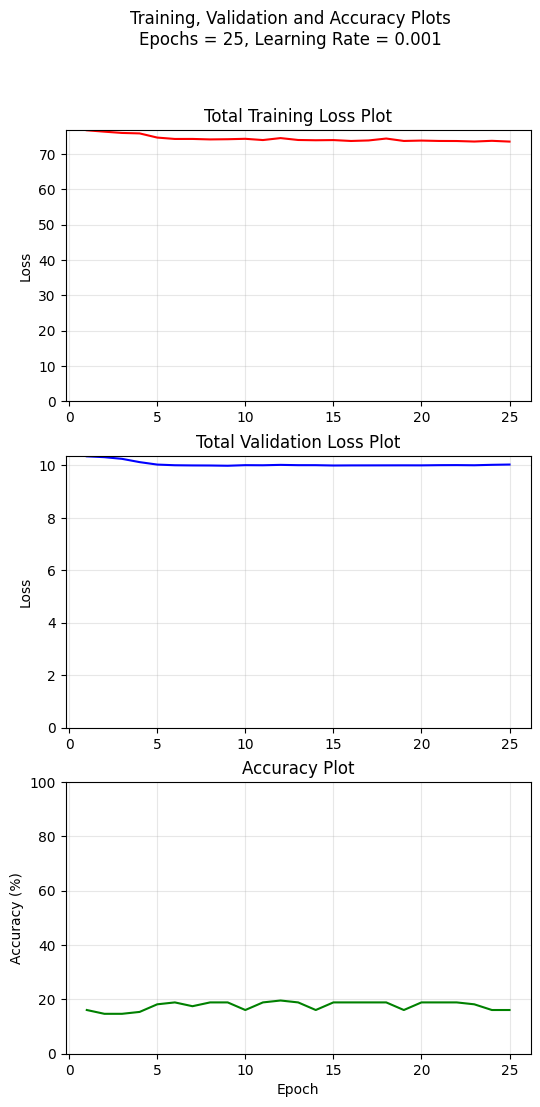

In [ ]:
# Initializing the RNN Model
EPOCHS = 25
LEARNING_RATE = 0.001
EMBEDDING_DIM = 16
HIDDEN_DIM = 32
model_rnn = LSTM(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, 8)

# Training it
train_and_validate_LSTM(model_rnn, train_loader_rnn, validation_loader_rnn, EPOCHS, LEARNING_RATE)

# **Phase 2: Multimodal Fusion**
# **Option A: Early Fusion**
Here I will implement Option A (Early Fusion), instead of Option B (Late Fusion).

In [ ]:
# Splitting the data into a train-validation-test split with a 80%-10%-10% proportion
# Here, y_cnn or y_rnn may be used as the true labels, since both the arrays are the same
X_spec_non_test_multimodal, X_spec_test_multimodal, X_text_non_test_multimodal, X_text_test_multimodal, y_non_test_multimodal, y_test_multimodal = train_test_split(
    X_cnn, X_rnn, y_cnn, test_size=0.1, random_state=42, stratify=y_cnn
)
X_spec_train_multimodal, X_spec_validation_multimodal, X_text_train_multimodal, X_text_validation_multimodal, y_train_multimodal, y_validation_multimodal = train_test_split(
    X_spec_non_test_multimodal, X_text_non_test_multimodal, y_non_test_multimodal, test_size=0.11, random_state=42, stratify=y_non_test_multimodal
)

In [ ]:
# Wrapping the split data into a PyTorch Dataset
class MultimodalDataset(Dataset):
    def __init__(self, spectrogram, tokenized_text, labels):
      self.spectrogram = torch.tensor(spectrogram).float()
      self.tokenized_text = torch.tensor(tokenized_text).int()
      self.labels = torch.tensor(labels).long()

    def __len__(self):
      return len(self.labels)

    def __getitem__(self, index):
      return self.spectrogram[index], self.tokenized_text[index], self.labels[index]

# Creating the DataLoader instances for training, validation and testing
# The validation and testing set is not shuffled since we must maintain the same data loading order to
# compare the validation loss among various epochs
train_loader_multimodal = DataLoader(MultimodalDataset(X_spec_train_multimodal, X_text_train_multimodal, y_train_multimodal), batch_size=32, shuffle=True)
validation_loader_multimodal = DataLoader(MultimodalDataset(X_spec_validation_multimodal, X_text_validation_multimodal, y_validation_multimodal), batch_size=32, shuffle=False)
test_loader_multimodal = DataLoader(MultimodalDataset(X_spec_test_multimodal, X_text_test_multimodal, y_test_multimodal), batch_size=32, shuffle=False)

In [ ]:
# Creating the MultiModal Architecture

class MultiModal_CNN_RNN(nn.Module):
  def __init__(self, cnn_channels, cnn_height, cnn_width, rnn_vocab_size, rnn_emb_dim, rnn_hidden_dim, output_dim):
    super().__init__()

    # Initializing the model parameters
    # The dimensions of the input data and the number of categorical classes for the CNN part
    self.cnn_channels = cnn_channels
    self.cnn_height = cnn_height
    self.cnn_width = cnn_width
    self.cnn_classes = output_dim
    # The vocabulary size and number of dimensions for the embeddings, hidden layers
    # and the output for the RNN part
    self.rnn_vocab_size = rnn_vocab_size
    self.rnn_emb_dim = rnn_emb_dim
    self.rnn_hidden_dim = rnn_hidden_dim
    self.rnn_output_dim = output_dim
    # The output dimensions of the Multimodal model are also the same
    self.multimodal_output_dim = output_dim

    # Creating the CNN part and its sequential layers up to the second last layer
    self.cnn_submodel = CNN(self.cnn_channels, self.cnn_height, self.cnn_width, self.cnn_classes)
    self.cnn_submodel_layers = nn.Sequential(*list(self.cnn_submodel.layers)[:-1])
    # Creating the RNN part and its fully connected layers up to the second last layer
    self.rnn_submodel = LSTM(self.rnn_vocab_size, self.rnn_emb_dim, self.rnn_hidden_dim, self.rnn_output_dim)
    self.rnn_submodel_fc_layers = nn.Sequential(*list(self.rnn_submodel.fc_layers)[:-1])

    # Defining the layers to normalize the bottleneck feature tensors from the CNN and RNN models
    # This is done because the numerical values in the CNN and RNN features may be at different scales
    self.audio_bottleneck_norm = nn.LayerNorm(64)
    self.text_bottleneck_norm = nn.LayerNorm(16)

    # Defining the Fully Connected Layers after the concatenation of the bottleneck feature
    # vectors from the CNN and RNN
    self.multimodal_fc_layers = nn.Sequential(
        # Here, the input tensor is the concatenation of the bottleneck feature tensors from the
        # CNN and RNN models, and so its total input features are (64 + 16 =) 80
        nn.Linear(80, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, self.multimodal_output_dim)
    )

  # Defining the forward pass
  def forward(self, spectrogram, text):
    # Bottleneck vector from the CNN
    cnn_bottleneck = self.cnn_submodel_layers(spectrogram)
    # Normalizing it
    cnn_bottleneck = self.audio_bottleneck_norm(cnn_bottleneck)

    # Embedding the input tokenized text for the RNN
    embedded_text = self.rnn_submodel.text_embed(text)
    # Processing the embedding through the LSTM
    output, (hidden_state, cell_state) = self.rnn_submodel.lstm(embedded_text)
    # Bottleneck vector from the RNN
    rnn_bottleneck = self.rnn_submodel_fc_layers(hidden_state[-1])
    # Normalizing it
    rnn_bottleneck = self.text_bottleneck_norm(rnn_bottleneck)

    # Concatenating the normalized bottleneck feature tensors
    concat_features = torch.cat((cnn_bottleneck, rnn_bottleneck), dim=1)

    # Passing it throught the Fully Connected Layers for the MultiModal architecture
    return self.multimodal_fc_layers(concat_features)

In [ ]:
# Creating the training and validation loop for the MultiModal model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_and_validate_MultiModal(model, train_loader, validation_loader, epochs, lr):
  model.to(device)

  # Using the Adam Optimizer
  optimizer = optim.Adam(model.parameters(), lr=lr)

  # Using the Categorical Cross Entropy Loss
  CCELoss = nn.CrossEntropyLoss()

  training_losses = []
  validation_losses = []
  validation_accuracies_pct = []

  for epoch in range(epochs):
    # Training:
    model.train()
    total_training_loss = 0

    for spectrogram, tokenized_text, label in train_loader:
      spectrogram = spectrogram.to(device)
      tokenized_text = tokenized_text.to(device)
      label = label.to(device)

      optimizer.zero_grad()

      # Forward pass
      predicted_label = model.forward(spectrogram, tokenized_text)

      # Calculating the loss
      loss = CCELoss(predicted_label, label)
      total_training_loss += loss.item()

      # Backpropagation
      loss.backward()

      # Optimizer step
      optimizer.step()

    # Printing the total training loss for that epoch:
    training_losses.append(total_training_loss)
    print(f"Epoch {epoch + 1}:")
    print(f"Training Loss = {total_training_loss:.4f}")

    # Validation:
    model.eval()
    total_validation_loss = 0
    correct_predictions = 0

    with torch.no_grad():
      for spectrogram, tokenized_text, label in validation_loader:
        spectrogram = spectrogram.to(device)
        tokenized_text = tokenized_text.to(device)
        label = label.to(device)

        # Forward pass
        predicted_label = model.forward(spectrogram, tokenized_text)

        # Calculating the loss
        loss = CCELoss(predicted_label, label)
        total_validation_loss += loss.item()

        # Calculating the accuracy
        # Obtaining the predictions from the tensors of class probabilities
        predictions = predicted_label.argmax(dim=1, keepdim=True)
        # Comparing the individual label predictions with the true labels and adding the
        # number of correct predictions to the total
        correct_predictions += predictions.eq(label.view_as(predictions)).sum().item()

    validation_accuracy = (correct_predictions/len(validation_loader.dataset))*100
    validation_losses.append(total_validation_loss)
    validation_accuracies_pct.append(validation_accuracy)
    # Printing the total validation loss and validation accuracy for that epoch:
    print(f"Validation Loss = {total_validation_loss:.4f}")
    print(f"Validation Accuracy = {validation_accuracy:.4f}%")
    print()

  # Plotting the training and validation loss plots along with the validation accuracy plot
  plt.figure(figsize=(6, 12))

  plt.subplot(3, 1, 1)
  plt.plot([(i+1) for i in range(epochs)], training_losses, color='red')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Training Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(3, 1, 2)
  plt.plot([(i+1) for i in range(epochs)], validation_losses, color='blue')
  plt.ylabel("Loss")
  plt.ylim(bottom=0)
  plt.title("Total Validation Loss Plot")
  plt.grid(True, alpha=0.3)

  plt.subplot(3, 1, 3)
  plt.plot([(i+1) for i in range(epochs)], validation_accuracies_pct, color='green')
  plt.ylabel("Accuracy (%)")
  plt.ylim(0, 100)
  plt.title("Accuracy Plot")
  plt.xlabel("Epoch")
  plt.grid(True, alpha=0.3)

  plt.suptitle(f"Training, Validation and Accuracy Plots\nEpochs = {epochs}, Learning Rate = {lr}")
  plt.show()

In [ ]:
# Creating the testing loop for the MultiModal model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def test_MultiModal(model, test_loader):
  model.to(device)

  # Testing:
  model.eval()
  correct_predictions = 0
  predictions_list = []

  with torch.no_grad():
    for spectrogram, tokenized_text, label in test_loader:
      spectrogram = spectrogram.to(device)
      tokenized_text = tokenized_text.to(device)
      label = label.to(device)

      # Forward pass
      predicted_label = model.forward(spectrogram, tokenized_text)

      # Calculating the accuracy
      # Obtaining the predictions from the tensors of class probabilities
      predictions = predicted_label.argmax(dim=1, keepdim=True)
      predictions_list.extend(predictions.cpu())
      # Comparing the individual label predictions with the true labels and adding the
      # number of correct predictions to the total
      correct_predictions += predictions.eq(label.view_as(predictions)).sum().item()

  test_accuracy = (correct_predictions/len(test_loader.dataset))*100
  # Printing the test accuracy:
  print(f"Test Accuracy = {test_accuracy:.4f}%")

  predictions_array = np.array(predictions_list)

  # Returning the predicted labels for the test dataset
  return predictions_array.flatten()

Epoch 1:
Training Loss = 76.1698
Validation Loss = 10.2368
Validation Accuracy = 13.2867%

Epoch 2:
Training Loss = 73.7956
Validation Loss = 10.4410
Validation Accuracy = 14.6853%

Epoch 3:
Training Loss = 71.0174
Validation Loss = 10.3981
Validation Accuracy = 15.3846%

Epoch 4:
Training Loss = 67.7027
Validation Loss = 11.6942
Validation Accuracy = 13.2867%

Epoch 5:
Training Loss = 70.2345
Validation Loss = 11.9180
Validation Accuracy = 17.4825%

Epoch 6:
Training Loss = 66.8984
Validation Loss = 9.5547
Validation Accuracy = 27.9720%

Epoch 7:
Training Loss = 64.0202
Validation Loss = 9.0791
Validation Accuracy = 30.0699%

Epoch 8:
Training Loss = 64.1542
Validation Loss = 8.9028
Validation Accuracy = 31.4685%

Epoch 9:
Training Loss = 62.3828
Validation Loss = 9.4764
Validation Accuracy = 24.4755%

Epoch 10:
Training Loss = 63.1392
Validation Loss = 8.9199
Validation Accuracy = 32.1678%

Epoch 11:
Training Loss = 63.1859
Validation Loss = 8.2541
Validation Accuracy = 31.4685%

Epo

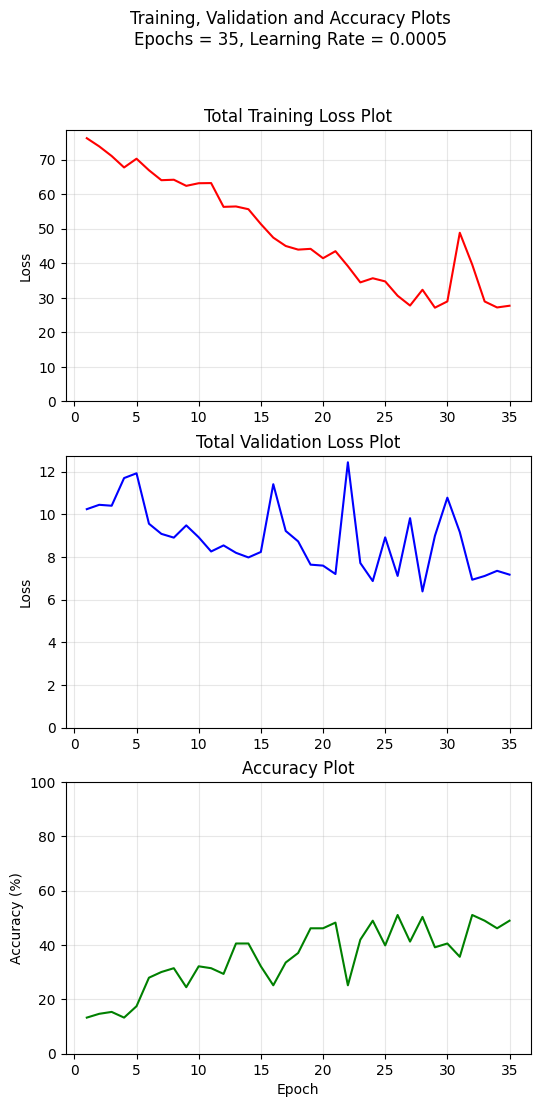

In [ ]:
# Initializing the MultiModal Model
EPOCHS = 35
LEARNING_RATE = 0.0005
EMBEDDING_DIM = 16
HIDDEN_DIM = 32
model_multimodal = MultiModal_CNN_RNN(1, 128, 282, vocab_size, EMBEDDING_DIM, HIDDEN_DIM, 8)

# Training it
train_and_validate_MultiModal(model_multimodal, train_loader_multimodal, validation_loader_multimodal, EPOCHS, LEARNING_RATE)

# **Phase 3: Evaluation and Analysis**
Testing all 3 models, plotting their respective confusion matrices and then comparing their accuracies.

In [ ]:
# Testing the trained CNN model
predictions_CNN = test_CNN(model_cnn, test_loader_cnn)

Test Accuracy = 59.0278%


Normalized Confusion Matrix for the CNN Model:


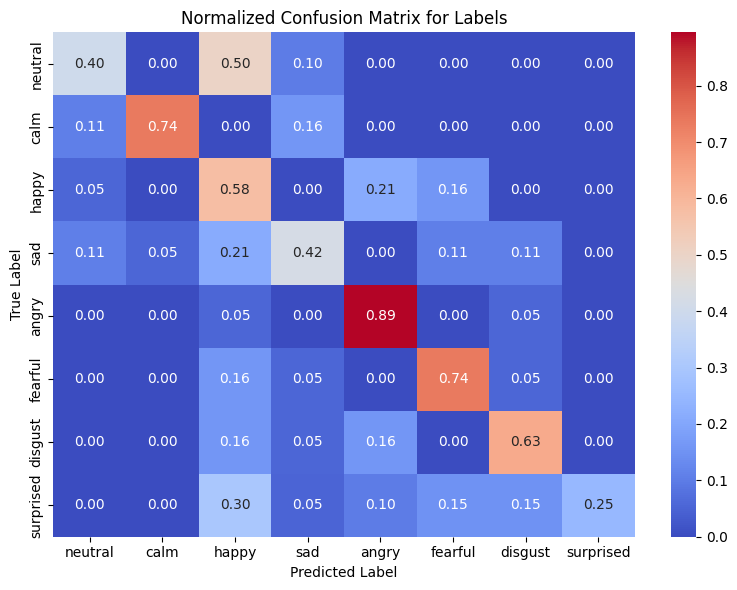

In [ ]:
# Plotting the Normalized Confusion Matrix for the CNN
print("Normalized Confusion Matrix for the CNN Model:")
plot_confusion_matrix(y_test_cnn, predictions_CNN)

In [ ]:
# Testing the trained RNN model
predictions_RNN = test_RNN(model_rnn, test_loader_rnn)

Test Accuracy = 17.3611%


Normalized Confusion Matrix for the RNN Model:


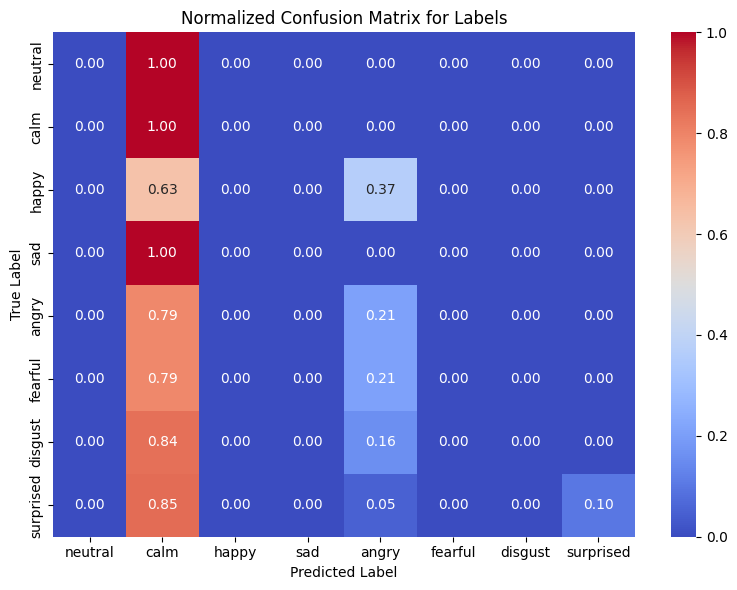

In [ ]:
# Plotting the Normalized Confusion Matrix for the RNN
print("Normalized Confusion Matrix for the RNN Model:")
plot_confusion_matrix(y_test_rnn, predictions_RNN)

In [ ]:
# Testing the trained MultiModal model
predictions_multimodal = test_MultiModal(model_multimodal, test_loader_multimodal)

Test Accuracy = 46.5278%


Normalized Confusion Matrix for the MultiModal Model:


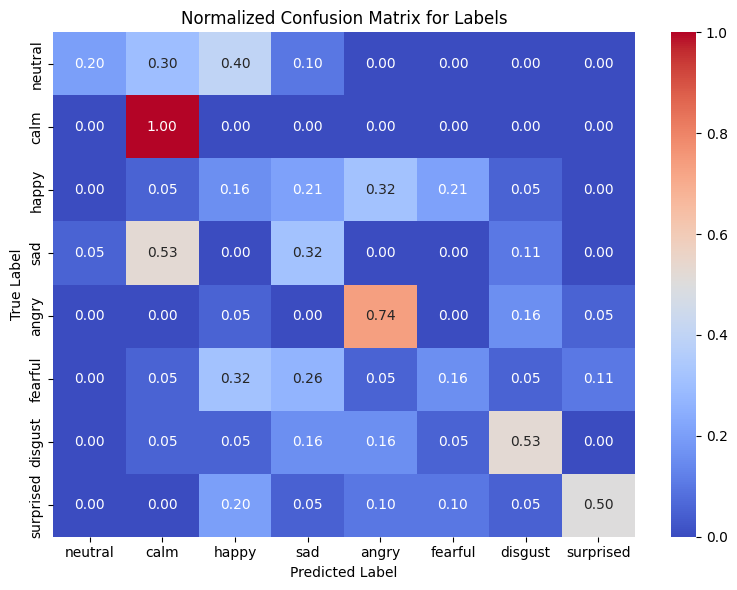

In [ ]:
# Plotting the Normalized Confusion Matrix for the MultiModal Model
print("Normalized Confusion Matrix for the MultiModal Model:")
plot_confusion_matrix(y_test_multimodal, predictions_multimodal)